In [13]:

method_name = 'DataMIL'
color_maps = {
    'no-live-only': (0.5, 0.5, 0.5),
    # 'All-Data': (0.7, 0.7, 0.7),
    'with-live-only': (0.7, 0.7, 0.7),
    # 'SR': 'C5',
    'all-data': 'C0',
    # 'BR': 'C1',
    'filter-episode': 'C2',
    'filter-timestep': 'C4',
    method_name: 'C3',
}

alpha_map = {
    'no-live-only': 1,
    'with-live-only': 1,
    # 'SR': 0.7,
    'all-data': 0.7,
    'filter-episode': 0.7,
    'filter-timestep': 0.7,
    # 'BR': 0.7,
    method_name: 1,
}

## REAL WORLD

In [14]:
method_list = ['no-live-only', 'with-live-only', 'all-data', 'filter-episode',  'filter-timestep']
_real_results = {
    'Shelve Item': {
        'full': {
                'no-live-only': 3/14,
                'with-live-only': 5/14,
                'all-data': 4/14,
                'filter-episode': 4/14,
                'filter-timestep': 8/14,
                'BR': 7/14,
                method_name: 7/14,
            }
    },
    'Franka-Deo': {
        'partial': {
                'no-live-only': 7/17,
                'with-live-only': 9/17,
                'all-data': 5/17,
                'filter-episode': 10/17,
                'filter-timestep': 10/17,
                'BR': 11/17,
                method_name: 15/17,
            },
        'full': {
                'no-live-only': 3/17,
                'with-live-only': 3/17,
                'all-data': 2/17,
                'filter-episode': 6/17,
                'filter-timestep': 5/17,
                'BR': 7/17,
                method_name: 12/17,
            }
    },

    'Tiago-Sink': {
        'partial': {
                'no-live-only': 18/39,
                'with-live-only': 17/39,
                'all-data': 18/39,
                'filter-episode': 23/39,
                'filter-timestep': 17/39,
                'BR': 21/39,
                method_name: 28/39,
            },
        'full': {
                'no-live-only': 13/39,
                'with-live-only': 17/39,
                'all-data': 14/39,
                'filter-episode': 18/39,
                'filter-timestep': 15/39,
                'BR': 18/39,
                method_name: 25/39,
            }
    },
}


real_results = {}
for task in _real_results:
    real_results[task] = {}
    for part in _real_results[task]:
        real_results[task][part] = {}
        for method in method_list:
            real_results[task][part][method] = _real_results[task][part][method] * 100

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_style('darkgrid')

def plot_real_task(results, plot_partial=False, plot_legend=False, linewidth=0):
    if plot_partial:
       pass

    full_results = results['full']

    # plot a bar graph with the data and show the labels in a legend
    x = np.arange(len(full_results))
    width = 0.3
    fig, ax = plt.subplots(figsize=(5, 5))
    keys = list(full_results.keys())
    # (0.3, 0.3, 0.3), 
    colors = [color_maps[k] for k in keys]

    for i, k in enumerate(keys):
        if linewidth > 0:
            ax.bar([width*((len(keys)+1)/2 - len(keys) + i)], full_results[k], width, capsize=5, label=k, color=color_maps[k], alpha=alpha_map[k], edgecolor='black', linewidth=linewidth)
        else:
            ax.bar([width*((len(keys)+1)/2 - len(keys) + i)], full_results[k], width, capsize=5, label=k, color=color_maps[k], alpha=alpha_map[k])

    # turn off x ticks
    ax.set_xticks([])
    plt.ylim([0, 85])
    plt.yticks(np.arange(20, 81, 20), fontsize=14)
    ax.spines[['right', 'top']].set_visible(False)
    if plot_legend:
        plt.legend(loc='upper left', fontsize=12, frameon=False, ncol=7, columnspacing=1, bbox_to_anchor=(1.15, 0.8))
    plt.tight_layout()
    return ax


/tmp/ipykernel_1721332/1542843927.py:33: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: 'resources/figures/shelve_item.pdf'

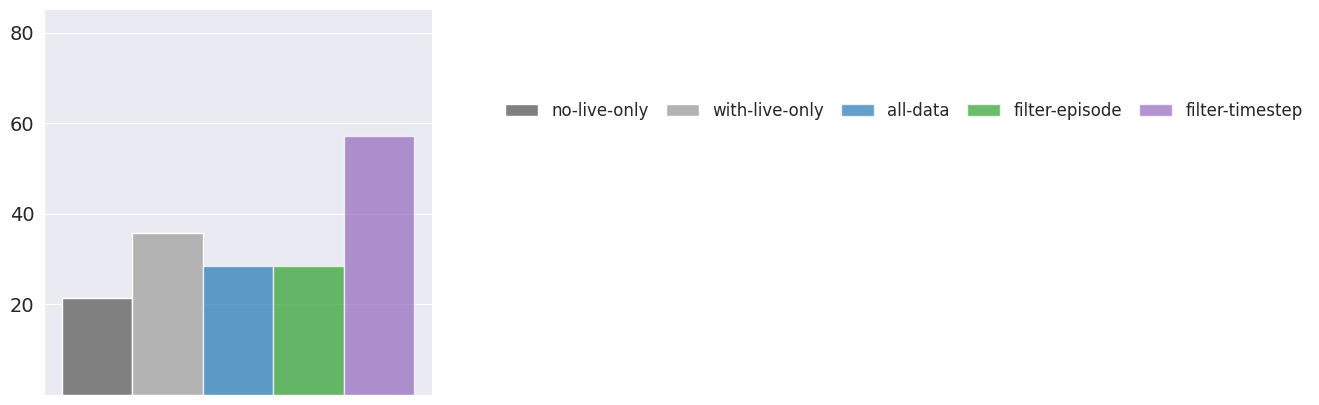

In [17]:
ax = plot_real_task(real_results['Shelve Item'], plot_partial=False, plot_legend=True)
# ax.legend(loc='upper left', fontsize=12, frameon=False, ncol=1, columnspacing=1, bbox_to_anchor=(1.15, 0.8))
plt.savefig('resources/figures/shelve_item.pdf', dpi=300, bbox_inches='tight')

<Axes: >

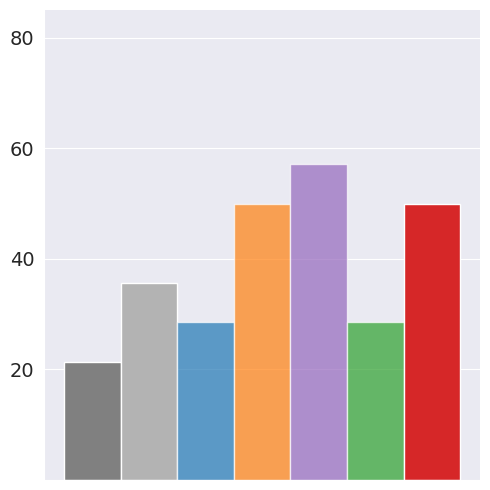

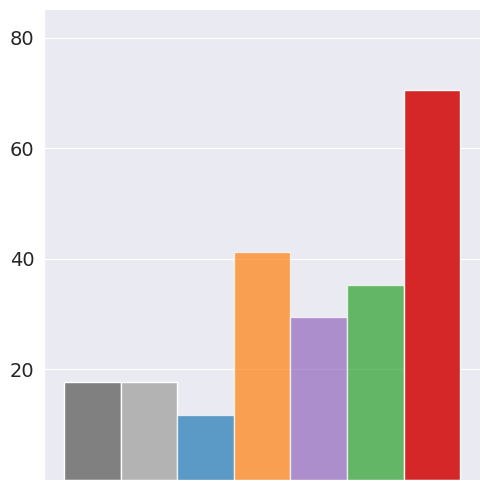

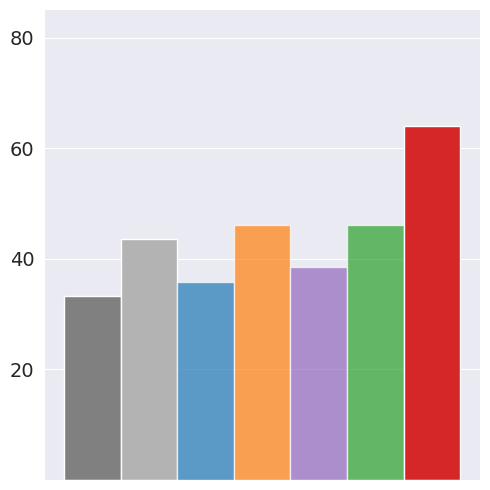

In [7]:
plot_real_task(real_results['Franka-Ball'], plot_partial=False)
# plt.savefig('assets/real_fig/franka_ball.pdf', dpi=300, bbox_inches='tight')

plot_real_task(real_results['Franka-Deo'], plot_partial=False)
# plt.savefig('assets/real_fig/franka_deo.pdf', dpi=300, bbox_inches='tight')

plot_real_task(real_results['Tiago-Sink'], plot_partial=False)
# plt.savefig('assets/real_fig/tiago_sink.pdf', dpi=300, bbox_inches='tight')

{'full': {'Target-Only': 24.13632119514472, 'Random': 32.317029375852904, 'AR': 25.41119011707247, 'BR': 45.776772247360476, 'STRAP': 41.67205343675932, 'Flow': 36.673130790777854, 'DataMIL': 61.563599798893925}}


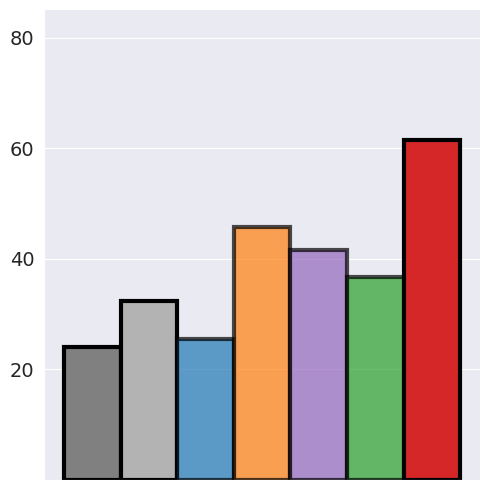

In [8]:
real_overall_results = real_results.copy()

real_avg_results = {}
for method in method_list:
    method_results = []
    for task in real_overall_results:
        method_results.append(real_overall_results[task]['full'][method])
    real_avg_results[method] = np.mean(method_results)

avg_results = {'full': real_avg_results}
print(avg_results)

# sns.set_style("white")
sns.set_style("darkgrid")
ax = plot_real_task(avg_results, linewidth=3)
# ax.set_facecolor((0.9, 0.9, 0.9))
# plt.savefig('assets/real_fig/avg.pdf', dpi=300, bbox_inches='tight')